<a href="https://colab.research.google.com/github/Areeba-Nizami/ML/blob/CNN-Development-for-Image-Classification/CNN_Development_for_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1.Dataset Loading and Preprocessing



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("\nSample label:", y_train[0])
print("Pixel value range:", X_train.min(), "to", X_train.max())

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2102s 12us/step
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)

Sample label: [6]
Pixel value range: 0 to 255


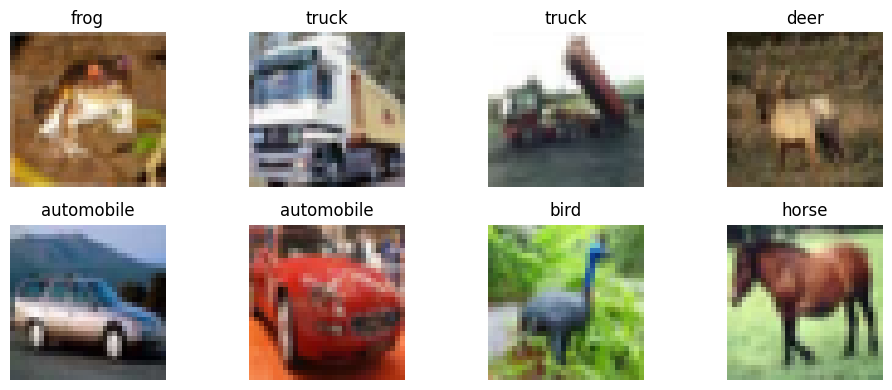

In [2]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [3]:
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("X_train_norm shape:", X_train_norm.shape)
print("y_train_cat shape:", y_train_cat.shape)
print("Pixel range after normalize:", X_train_norm.min(), "to", X_train_norm.max())

X_train_norm shape: (50000, 32, 32, 3)
y_train_cat shape: (50000, 10)
Pixel range after normalize: 0.0 to 1.0


# 2: CNN Model Architecture Design

In [4]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

# 3: Data Augmentation Implementation

In [5]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train_norm)

# 4. Model Training and Evaluation

In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    datagen.flow(X_train_norm, y_train_cat, batch_size=64),
    epochs=15,
    validation_data=(X_test_norm, y_test_cat),
    verbose=1
)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 100s 125ms/step - accuracy: 0.3720 - loss: 1.7060 - val_accuracy: 0.4650 - val_loss: 1.4745
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 94s 120ms/step - accuracy: 0.4909 - loss: 1.4013 - val_accuracy: 0.5556 - val_loss: 1.2323
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 93s 119ms/step - accuracy: 0.5427 - loss: 1.2750 - val_accuracy: 0.5977 - val_loss: 1.1318
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 141s 118ms/step - accuracy: 0.5749 - loss: 1.1914 - val_accuracy: 0.6182 - val_loss: 1.0789
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 94s 120ms/step - accuracy: 0.5967 - loss: 1.1354 - val_accuracy: 0.6245 - val_loss: 1.0815
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 93s 119ms/step - accuracy: 0.6158 - loss: 1.0838 - val_accuracy: 0.6361 - val_loss: 1.0515
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 92s 118ms/step - accuracy: 0.6311 - loss: 1.0439 - val_accuracy: 0.6545 - val_loss: 0.9830
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 91s 116ms/step - accuracy: 0.6419 - loss:

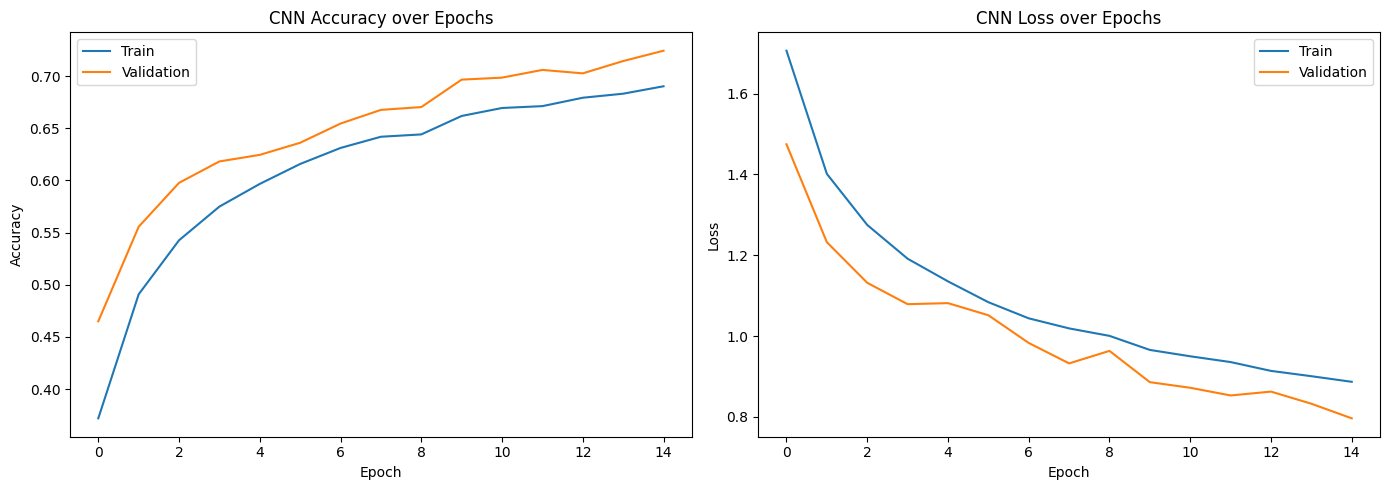

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('CNN Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('CNN Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('cnn_accuracy_loss.png', dpi=300)
plt.show()

In [9]:
test_loss, test_acc = model.evaluate(X_test_norm, y_test_cat, verbose=0)
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

Final Test Accuracy: 0.7243
Final Test Loss: 0.7965


# 5. Feature Map Visualization

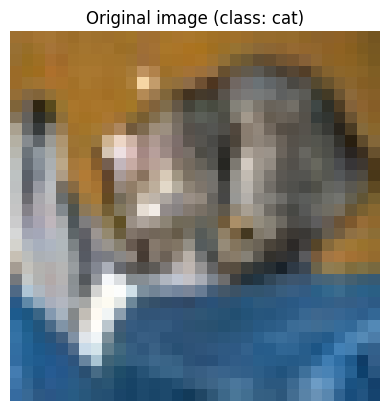

In [10]:
img = X_test_norm[0]
img_batch = np.expand_dims(img, axis=0)

plt.imshow(img)
plt.title(f"Original image (class: {class_names[y_test[0][0]]})")
plt.axis('off')
plt.show()

In [11]:
layer_outputs = [layer.output for layer in model.layers if 'conv2d' in layer.name]
feature_map_model = keras.Model(inputs=model.inputs, outputs=layer_outputs)

feature_maps = feature_map_model.predict(img_batch)

print("Number of conv layers captured:", len(feature_maps))
for i, fmap in enumerate(feature_maps):
    print(f"Layer {i} feature map shape:", fmap.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
Number of conv layers captured: 3
Layer 0 feature map shape: (1, 30, 30, 32)
Layer 1 feature map shape: (1, 13, 13, 64)
Layer 2 feature map shape: (1, 4, 4, 64)


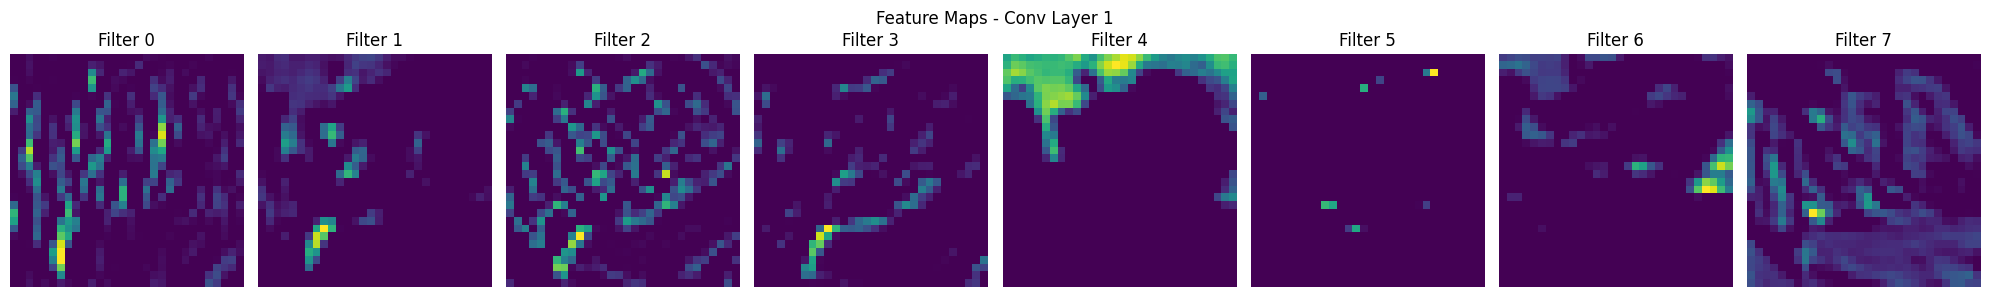

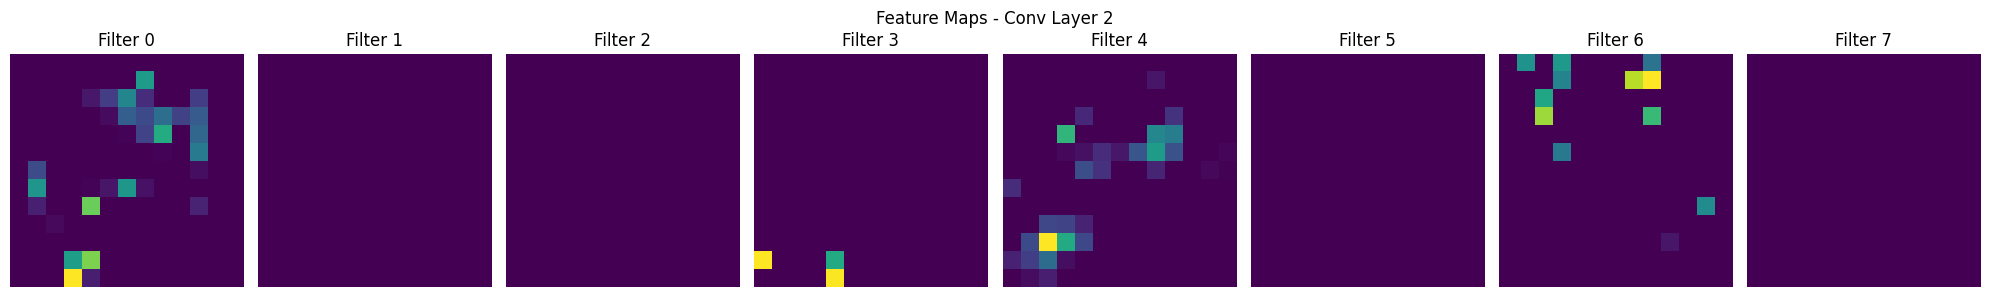

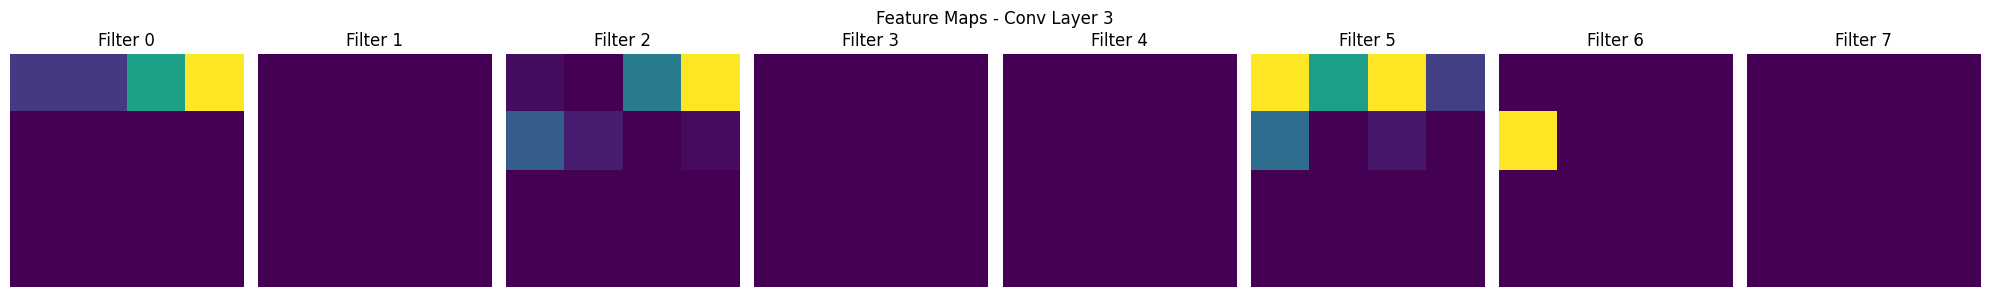

In [12]:
def plot_feature_maps(fmap, layer_num, num_filters=8):
    fig, axes = plt.subplots(1, num_filters, figsize=(20, 3))
    for i in range(num_filters):
        axes[i].imshow(fmap[0, :, :, i], cmap='viridis')
        axes[i].axis('off')
        axes[i].set_title(f'Filter {i}')
    fig.suptitle(f'Feature Maps - Conv Layer {layer_num}')
    plt.tight_layout()
    plt.savefig(f'feature_maps_layer_{layer_num}.png', dpi=300)
    plt.show()

plot_feature_maps(feature_maps[0], layer_num=1, num_filters=8)
plot_feature_maps(feature_maps[1], layer_num=2, num_filters=8)
plot_feature_maps(feature_maps[2], layer_num=3, num_filters=8)

In [13]:
print("X_test_norm shape:", X_test_norm.shape)
print("y_test_cat shape:", y_test_cat.shape)

X_test_norm shape: (10000, 32, 32, 3)
y_test_cat shape: (10000, 10)


**About data augmentation**

In the earlier MNIST project, the ReLU model started overfitting. That means training accuracy kept going up but validation accuracy started going down, which showed the model was just memorizing the training images instead of really learning.

This CNN did not do that. Validation accuracy actually stayed higher than training accuracy almost the whole time, and validation loss stayed lower than training loss too. Both numbers kept improving all the way to the last epoch. This happened because of data augmentation. During training, the model was shown randomly rotated, shifted, and flipped versions of the images, which made training harder on purpose. Because of this, the model could not just memorize exact images. It had to learn the general pattern of what a cat or a truck looks like, no matter how it was rotated or positioned. This is likely why overfitting did not happen this time.

**About the feature maps**

When looking at the feature maps from the first convolutional layer, you can still somewhat see the outline of the original cat image. This layer seems to be picking up on simple things like edges and shapes.

By the second layer, the feature maps are smaller and look more blocky and abstract. Some filters show strong activity and some show almost nothing for this image, which is normal since different filters are looking for different patterns and not every pattern shows up in every image.

By the third layer, the feature maps are very small, just 4 by 4 pixels, and do not look like the original image at all anymore. This shows that the deeper the network goes, the more abstract and less human readable the information becomes, since the model is no longer trying to preserve the image, it is trying to extract useful patterns for classification.

**About overall performance**

The final model reached about 72.4 percent accuracy on the test set, with a loss of about 0.80. Since CIFAR-10 has real, colorful photos across 10 completely different categories, this is a solid result for a fairly simple CNN trained for only 15 epochs. The model could probably do even better with more epochs or a bigger architecture, but this result shows the model actually learned real patterns from the images, which is also supported by the way the feature maps went from simple shapes in the early layers to abstract patterns in the deeper layers.

